## Astronomy 3350
### Autumn 2025
#### Computational essay 2

Here we examine some of the data the went into the analysis of the transit of
planet Kepler 90g, as presented by [Shaw et al. (2025)](https://ui.adsabs.harvard.edu/abs/2025AJ....170..146S/abstract).  We want to
- demonstrate that the data from MDM, taken by Terndrup and students, shows evidence for _planetary egress_ (meaning the end of the planetary transit).
- assign errors to the measurements based on the variance in the data.

This is an example of a _partially completed notebook_: it contains bits of code, where
the code needs to be verified and documented, and only fragments of a strong narrative
appropriate for a computational essay.

Instructions:
- Solve each problem, using the specific methods stated in each problem.
- Add narrative to make your essay in the form of _an internal research report_.  Such a report will emphasize methods, results, and analysis. It should be readable by new students in the group, so you will need to explain statistical and computational methods, and make the code readable and complete.
- Submit your completed notebook via file upload to Carmen canvas.

Each problem is worth 10 points, with an additional 25 points for the quality of your essay.

Due date: __9:00 p.m. on Friday, October 24__.  As always, you have 48 hours after the due date to submit
without penalty. 

We begin by importing any codes we need.

In [1]:
# Get plotting codes
import matplotlib.pyplot as plt

### Problem 0

List all team members!

- Jungyu Baeck

Carefully read the abstract of the paper by Shaw et al., and write a brief narrative explaining
what this notebook is about.  Then, after you have completed all the calculations, return to
this introductory narrative and write a summary of your principal conclusions. This would act
like an _executive summary_ of this notebook.

This computational essay investigates photometric data collected from the MDM Observatory to analyze the 2024 May transit of Kepler-90 g, one of the outer planets in the eight-planet Kepler-90 system. According to Shaw et al. (2025), Kepler-90 g and h exhibit strong transit-timing variations (TTVs) that reveal their mutual gravitational interactions. By combining new ground-based observations with Kepler photometry and a decade of radial-velocity measurements, they refined the planets’ orbital ephemerides and masses.

In this notebook, my goal is to examine the supporting MDM photometric data to verify the presence of planetary egress, the end phase of the transit, and to evaluate the precision and stability of the observations.

I implemented Python routines to compute statistical quantities (mean, standard deviation, and standard error), construct an observation data class, and read in photometry for two nights surrounding the Kepler-90 g event. I produced:
- Airmass vs. Julian Date to track observing conditions.
- Target flux vs. airmass and vs. time to assess atmospheric attenuation.
- Relative (differential) flux of Kepler-90 compared to comparison stars.

I cleaned the data by identifying outliers through 4-σ rejection, rescaled the relative flux by its mean, and binning analysis to estimate observational errors.

I finally showed The raw photometry showed the expected decrease in flux with increasing airmass due to atmospheric extinction.
After differential correction, both nights displayed stable relative flux around unity with scatter at the 0.1–0.7 % level. The small brightness increasing trends on night 2 within measurement uncertainty and likely due to changes in airmass or transparency rather than a true astrophysical signal.
Statistical slicing of the data found no brightness change larger than 2 σ, showing that Kepler-90’s light remained constant within observational uncertainty.

My analysis supports the findings of Shaw et al. by showing that the MDM observations show evidence for planetary egress without significant residual variability in Kepler-90’s brightness. This project shows how precise differential photometry and statistical treatment of noise can reveal planetary signals and validate large scale dynamical studies of exoplanetary systems.

### Problem 1

Below are _code stubs_ for two statistical functions.
- Fully document these codes using docstrings.
- Write a markdown cell justifying why they work.  Do this either with LaTeX formulae, or by a hyperlink to a reference the reader can look up. Include a _design statement_ that explains we have chosen to do store data as Python lists.
- Test the functions using lists of numbers which yield known values.  Use any values you want, but you could generate lists where the statistics are immediately apparent.  One such list would contain an equal number of zeroes and ones.
- Write a function to compute the _standard error of the mean_ for values stored in a list.

The formula of mean and standard deviation are:
$$
\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i
$$
$$
\sigma = \sqrt{\langle x^2 \rangle - \langle x \rangle^2}
$$


In [2]:
def myavg(mylist):
    """
    Compute the mean of numerical data stored in a list.

    Parameters
    mylist : list of float
    The data values for which the average will be computed.
    
    return
    Formula:
    mean = (Σx_i) / N
    """
    return sum(mylist) / len(mylist)

In [3]:
def mystd(mylist):
    """
    Compute the standard deviation of numerical data stored in a list.

    Parameters
    mylist : list of float
        The data values for which the standard deviation is computed.
        
    return
    Formula:
        σ = sqrt( <x²> - <x>² )
    where:
        <x> = mean of x-values,
        <x²> = mean of squared x-values

    """
    squares = [ x**2 for x in mylist ]
    variance = myavg(squares) - (myavg(mylist))**2
    stdev = variance**0.5
    return stdev

In [4]:
testlist = [0, 1, 0, 1]  # mean = 0.5, std = 0.5, sem = 0.25
print("Mean =", myavg(testlist))
print("Standard Deviation =", mystd(testlist))

Mean = 0.5
Standard Deviation = 0.5


standard error of the mean (SEM) represents the expected uncertainty of the sample meanrepresents the expected uncertainty of the sample mean:
$$
\text{SEM} = \frac{\sigma}{\sqrt{N}}
$$

In [5]:
def mysem(mylist):
    """
    Compute the standard error of the mean (SEM) for numerical data.

    Parameters
    mylist : list of float
        Data values for which the SEM will be computed.

    Returns
    formula:
        Standard error of the mean: σ / sqrt(N)

    """
    return mystd(mylist) / (len(mylist) ** 0.5)

In [6]:
print("Standard Error =", mysem(testlist))

Standard Error = 0.25


### Problem 2

Write out a description of the format of the input data files, then explain
how the class object below is useful for storing the data.  You will need to
explain that were are obtaining _relative photometry_, which is the ratio of
image counts in the target star (Kepler 90) to the average of the counts in
a set of comparison stars.  It is a key point that we do not know the number
of comparison stars in advance.

The input data files contain photometric measurements taken during the transit of the exoplanet Kepler 90g. Each observation corresponds to a single image frame from the telescope. Each row in the data file are:

JD: Julian Date

Airmass: A measure of how much atmosphere the starlight passed through.

Target: The measured image counts (flux) from the target star.

comparison: The measured image counts from one or more comparison stars used to correct for atmospheric and instrumental effects. The number of these columns may vary between data files.

Because the number of comparison stars can differ for each dataset, we cannot assume a fixed number of columns. Instead, we need to read an arbitrary number of comparison-star flux values and average them for each observation.


Relative photometry is:
$$
\text{Relative Flux} = \frac{F_{\text{target}}}{\langle F_{\text{comparison}} \rangle}
$$

where $ F_{\text{target}} $ is the target star’s flux, and  
$\langle F_{\text{comparison}} \rangle$is the average flux from all comparison stars.

In [7]:
# Define object class

class observation:
    def __init__(self):
        self.jd = 0.0         # Time of observation (Julian Date)
        self.airmass = 0.00  # Atmospheric path length
        self.target = 0.00 # Flux of the target star (Kepler 90)
        self.comparison = [] # List of fluxes from all comparison stars
        self.relphot = 0.0 # Relative photometry = target / mean(comparison)
        self.fscaled = 0.0 # Scaled flux (normalized for analysis)

### Problem 3

Improve the code documentation for this function, and write a description in Markdown
explaing how the code works to slice up a text file with comments and numbers.

In [8]:
def get_data(filename):
    """
    Reads a file and returns data

    Returns
    list[observation]
        A list of observation objects. Each object holds:
        jd : float — time of observation (Julian Date)
        airmass : float — path length through the atmosphere
        target : float — flux of the target star (Kepler 90)
        comparison : list[float] — fluxes from one or more comparison stars

    notes:
    Lines beginning with '#' are skipped as comments.
    The number of comparison stars is not known in advance.
    Each line is split into words
    This function creates a new observation object for each valid line
    """
    with open(filename, 'r') as f:
        lines = f.readlines()

    datablock = []

    for line in lines:
        if line[0] == '#':
            ;        # Do nothing
        else:
            obs = observation()
            words = line.split()
            obs.jd = float(words[1])
            obs.airmass = float(words[2])
            obs.target = float(words[3])
            cflux = []               
            for cword in words[4: ]:
                cflux.append(float(cword))      
            obs.comparison = cflux.copy()
            datablock.append(obs)

    return datablock

The get_data() function reads a text file that contains both comments (lines beginning with #) and numeric data (photometric measurements). Its purpose is to separate these two types of lines and convert the data lines into usable numerical values for later analysis.

### Problem 4

The code stubs below work on a datafile that contains test values.
- For each of the two data files with real Kepler 90 data, read the files into two collections
with different names, then plot air mass as a function of the Julian date of
observation.
- In an example of code factorization, replace the fixed limits on the y-axis with
airmass values computed from the minimum or maximum of the values in the data files with a
small bit of space above and below.  You can use Python builtin functions for this,
as in "my upper limit is the minumum value minus 0.05" (in code, not words!).
- Explain what the airmass is, and incude a hyperlink to a good reference for further information.
- Look up the calendar dates appropriate for the Julian dates and set plot titles appropriately.

You might want to look up [matplotlib point styles (or markers)](https://matplotlib.org/stable/api/markers_api.html).  Also be careful to use different names for
lists with extracted data so you keep track of which night is which.

To convert JD into calender date, we used USNO Julian date converter - https://aa.usno.navy.mil/data/JulianDate.

Airmass is the relative path length that starlight travels through Earth’s atmosphere. it’s ≈1 at the zenith, increases toward the horizon, and is used to model atmospheric extinction in photometry. https://en.wikipedia.org/wiki/Air_mass_(astronomy)

In [9]:
def extract_jd_airmass(obs_list):
    return [o.jd for o in obs_list], [o.airmass for o in obs_list]

def padded_limits(values, pad=0.05, invert=True):
    """
    Return (ymin, ymax) with a small pad; invert=True returns limits in descending order.
    
    """
    vmin, vmax = min(values), max(values)
    lo, hi = vmin - pad, vmax + pad
    if invert:
        return hi, lo  # plot with decreasing airmass upwards
    return lo, hi

def jd_span(jds):
    return f"JD {min(jds):.5f}–{max(jds):.5f}"

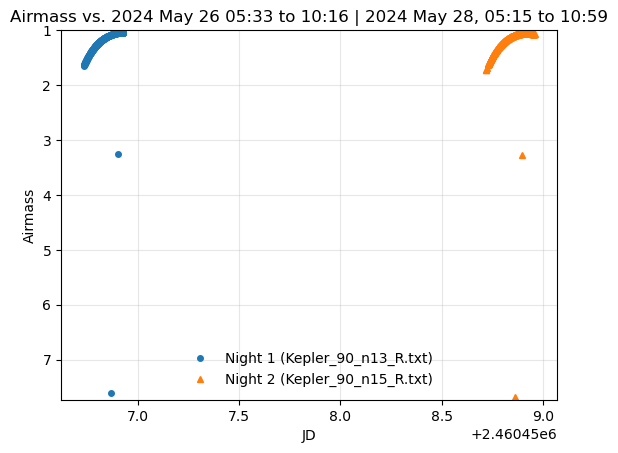

jd1 JD 2460456.73141–2460456.92814
jd2 JD 2460458.71935–2460458.95822


In [10]:
# filename = 'photdata.txt'
file1 = 'Kepler_90_n13_R.txt'  # night A
file2 = 'Kepler_90_n15_R.txt'  # night B

night1 = get_data(file1)
night2 = get_data(file2)

# Extract lists from larger collection
jd1, am1 = extract_jd_airmass(night1)
jd2, am2 = extract_jd_airmass(night2)

# Scribe the plot
fig, ax = plt.subplots() 

ax.plot(jd1, am1, 'o', markersize=4, label=f'Night 1 ({file1})')
ax.plot(jd2, am2, '^', markersize=4, label=f'Night 2 ({file2})')

# auto y-limits with padding
yl1, yh1 = padded_limits(am1 + am2, pad=0.05, invert=True)
ax.set_ylim(yl1, yh1)

ax.set_xlabel('JD')
ax.set_ylabel('Airmass')
ax.set_title(f'Airmass vs. 2024 May 26 05:33 to 10:16 | 2024 May 28, 05:15 to 10:59')

ax.grid(True, alpha=0.3)
ax.legend(frameon=False)
plt.show()

print("jd1", jd_span(jd1))
print("jd2", jd_span(jd2))

### Problem 5

For each of the two datasets, plot the counts in Kepler 90 as a function of Julian date
and as a function of air mass.  Describe any trends you see, and explain these trends
in light of the idea that the atmosphere attenuates the light of stars.  In this and
other plots, you should add labels and titles and set plot limits as needed.  As always,
make improvements to the code documentation whenever possible.

In [11]:
# Extract data for each night
jd1 = [obs.jd for obs in night1]
am1 = [obs.airmass for obs in night1]
counts1 = [obs.target for obs in night1]

jd2 = [obs.jd for obs in night2]
am2 = [obs.airmass for obs in night2]
counts2 = [obs.target for obs in night2]


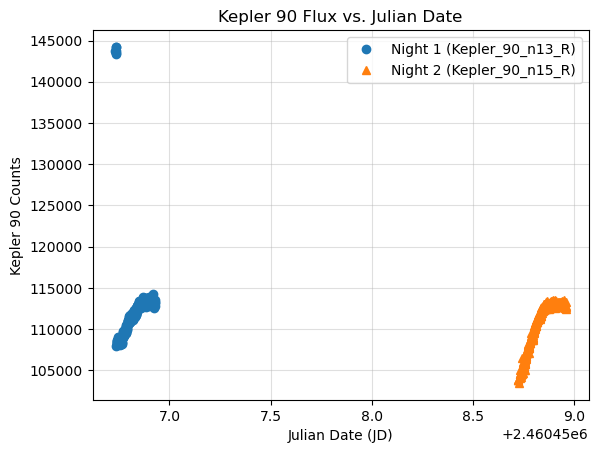

In [12]:

# Plot 1: target counts vs julian Date
fig, ax = plt.subplots()
ax.plot(jd1, counts1, 'o', label='Night 1 (Kepler_90_n13_R)')
ax.plot(jd2, counts2, '^', label='Night 2 (Kepler_90_n15_R)')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Kepler 90 Counts')
ax.set_title('Kepler 90 Flux vs. Julian Date')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()



These plots show how the observed brightness (counts) of the target star Kepler 90 varies with Julian Date and with airmass for two nights of observation.

**Counts vs. JD:**
The brightness may drift gradually over time due to atmospheric transparency changes, for example increasing humidity or clouds, or due to telescope tracking and instrumental effects. If the light curve shows a smooth dip and recovery, that could also trace the transit egress region mentioned in the assignment. It seems that there are these observation errors counts of about 145000 in night1. both counts are quite within 100000 - 115000 with similar shape.


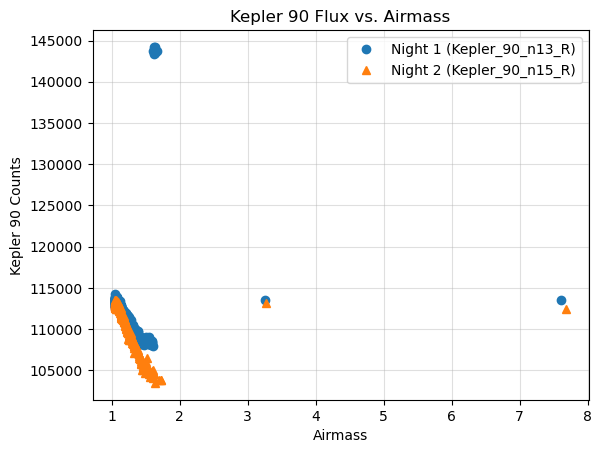

In [13]:
# Plot 2: target counts vs airmass
fig, ax = plt.subplots()
ax.plot(am1, counts1, 'o', label='Night 1 (Kepler_90_n13_R)')
ax.plot(am2, counts2, '^', label='Night 2 (Kepler_90_n15_R)')
ax.set_xlabel('Airmass')
ax.set_ylabel('Kepler 90 Counts')
ax.set_title('Kepler 90 Flux vs. Airmass')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()


**Counts vs. Airmass:**
Typically, counts decrease as airmass increases because light traveling through more atmosphere experiences stronger extinction 
$$
I = I_0 e^{-kX}
$$

where $I$ is the observed intensity,  
$ I_0 $ is the true intensity,  
$k$ is the extinction coefficient, and  
$X$ is the airmass.


### Problem 6

- Compute the relative brightness of Kepler 90 compared to the
average of the comparison stars on each night.
- Plot these with respect to Julian date, and discuss any trends you see.
- Compute and report the mean, the standard deviation, and standard error of the mean.

In [14]:
def find_rf(star, comp):
    """
    Compute relative flux (differential photometry) for one observation.

    Relative flux = target_flux / average(comparison_fluxes)
    """
    return star / myavg(comp)

# Compute relative flux for both nights
for obs in night1:
    obs.relphot = find_rf(obs.target, obs.comparison)
for obs in night2:
    obs.relphot = find_rf(obs.target, obs.comparison)

# --- Extract for plotting and statistics ---
jd1 = [obs.jd for obs in night1]
rf1 = [obs.relphot for obs in night1]

jd2 = [obs.jd for obs in night2]
rf2 = [obs.relphot for obs in night2]


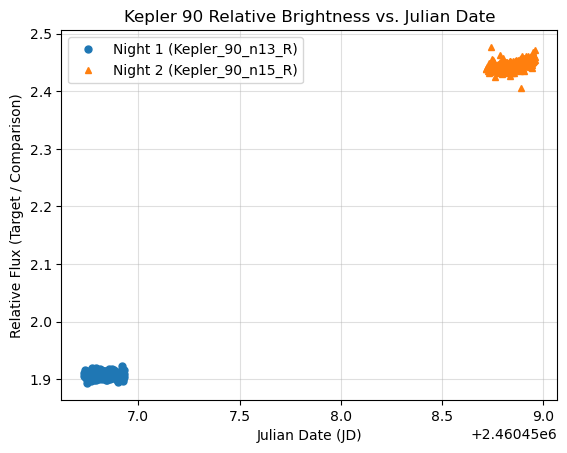

In [15]:
# Plot relative flux vs JD
fig, ax = plt.subplots()
ax.plot(jd1, rf1, 'o', markersize=5, label='Night 1 (Kepler_90_n13_R)')
ax.plot(jd2, rf2, '^', markersize=5, label='Night 2 (Kepler_90_n15_R)')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Relative Flux (Target / Comparison)')
ax.set_title('Kepler 90 Relative Brightness vs. Julian Date')
ax.grid(True, alpha=0.4)
ax.legend()
plt.show()

In [16]:
# Compute mean, standard deviation, SEM for each night
def stats(values):
    mean = myavg(values)
    sd = mystd(values)
    sem = mysem(values)
    return mean, sd, sem

mean1, sd1, sem1 = stats(rf1)
mean2, sd2, sem2 = stats(rf2)

print(f"Night 1 (n13_R): Mean={mean1:.5f}, SD={sd1:.5f}, SEM={sem1:.5f}")
print(f"Night 2 (n15_R): Mean={mean2:.5f}, SD={sd2:.5f}, SEM={sem2:.5f}")

Night 1 (n13_R): Mean=1.90673, SD=0.00463, SEM=0.00026
Night 2 (n15_R): Mean=2.44526, SD=0.00774, SEM=0.00040


0.0036904980126757536


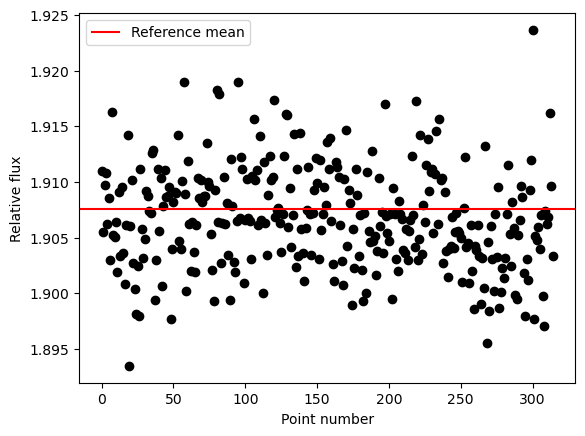

In [17]:
#can we do better?
# compute sigma for aslice of the data
starphot = rf1

datasig = mystd(starphot[ : 13])
datamean = myavg(starphot[ : 13])
print(datasig)

fig, ax = plt.subplots()
ax.plot(starphot, 'ok')
ax.axhline(datamean, color='red', lw=1.5, label='Reference mean')
ax.set_xlabel('Point number')
ax.set_ylabel('Relative flux')
ax.legend()
plt.show()

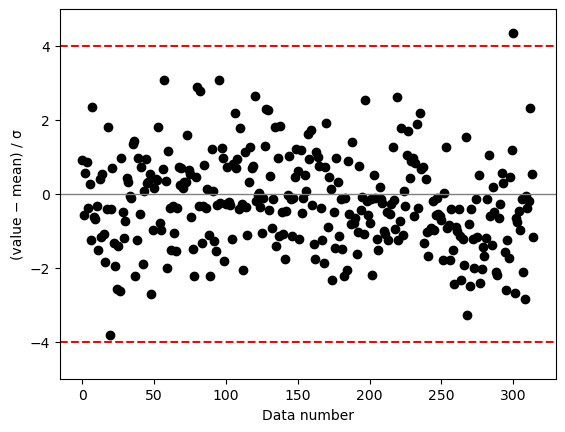

Outlier indices (≥4σ): [300]


In [18]:
# How many sigmas away is each point?

siglist = [(v - datamean) / datasig for v in starphot]

fig, ax = plt.subplots()
ax.plot(siglist, 'ok')
ax.axhline(0, color='gray', lw=1)
ax.axhline(4, color='red', ls='--')
ax.axhline(-4, color='red', ls='--')
ax.set_xlabel('Data number')
ax.set_ylabel('(value − mean) / σ')
ax.set_ylim(-5, 5)
plt.show()

# Identify any outliers beyond ±4σ
outliers = [i for i, s in enumerate(siglist) if abs(s) >= 4]
print(f"Outlier indices (≥4σ): {outliers}")


0.00414375004850609


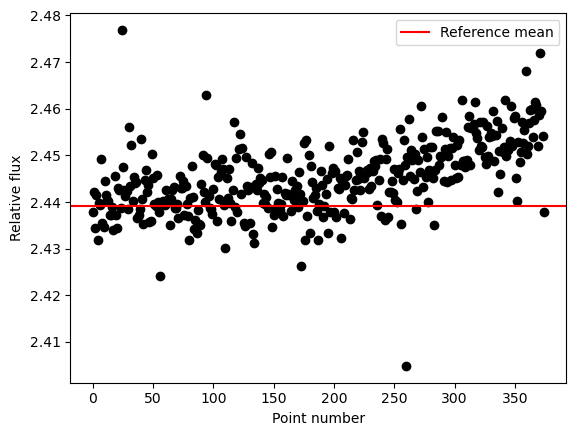

In [19]:
# compute sigma for aslice of the data
starphot2 = rf2

datasig2 = mystd(starphot2[ : 20])
datamean2 = myavg(starphot2[ : 20])
print(datasig2)

fig, ax = plt.subplots()
ax.plot(starphot2, 'ok')
ax.axhline(datamean2, color='red', lw=1.5, label='Reference mean')
ax.set_xlabel('Point number')
ax.set_ylabel('Relative flux')
ax.legend()
plt.show()


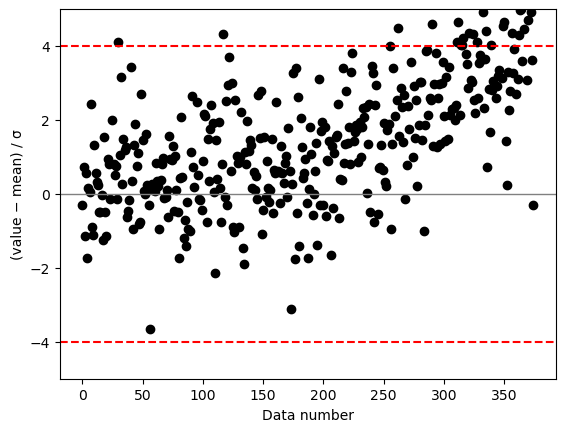

Outlier indices (≥4σ): [24, 30, 94, 117, 260, 262, 272, 290, 306, 311, 312, 314, 315, 316, 317, 321, 324, 327, 332, 335, 339, 342, 347, 349, 350, 356, 359, 362, 363, 364, 366, 367, 368, 370, 371, 372]


In [20]:
# How many sigmas away is each point?

siglist2 = [(v - datamean2) / datasig2 for v in starphot2]

fig, ax = plt.subplots()
ax.plot(siglist2, 'ok')
ax.axhline(0, color='gray', lw=1)
ax.axhline(4, color='red', ls='--')
ax.axhline(-4, color='red', ls='--')
ax.set_xlabel('Data number')
ax.set_ylabel('(value − mean) / σ')
ax.set_ylim(-5, 5)
plt.show()

# Identify any outliers beyond ±4σ
outliers2 = [i for i, s in enumerate(siglist2) if abs(s) >= 4]
print(f"Outlier indices (≥4σ): {outliers2}")

second night tends increasing

first night tends constant

more flux on second night

### Problem 7

Using the plots, identify a data range which can be used to identify points that
are probably erroneous.  Clean the lists and make plots of the relative brightness
of the cleaned data.  Report the mean, standard deviation, and standard error
of the mean for the cleaned data on each night.

Bad points have indices [300]
Mean star flux = 1.90667
Standard deviation = 0.00453
Standard error of mean = 0.00026


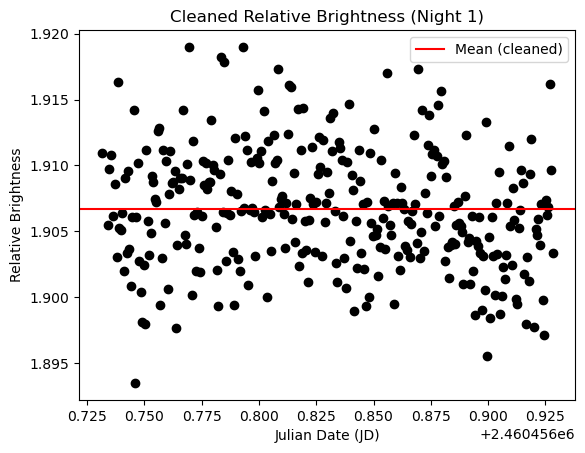

In [21]:
# Identify bad points
low_cut, high_cut = 1.89, 1.92

klist = [k for k, v in enumerate(starphot) if v < low_cut or v > high_cut]
print('Bad points have indices', klist)

# Copy a new list of observations
clean_data = [o for k, o in enumerate(night1) if k not in klist]
clean_obstimes = [o.jd for o in clean_data]
clean_starphot = [o.relphot for o in clean_data]

# Compute statistics
mean_clean = myavg(clean_starphot)
sd_clean   = mystd(clean_starphot)
sem_clean  = mysem(clean_starphot)

print(f"Mean star flux = {mean_clean:.5f}")
print(f"Standard deviation = {sd_clean:.5f}")
print(f"Standard error of mean = {sem_clean:.5f}")

# Plot cleaned data
fig, ax = plt.subplots()
ax.plot(clean_obstimes, clean_starphot, 'ok')
ax.axhline(mean_clean, color='r', label='Mean (cleaned)')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Relative Brightness')
ax.set_title('Cleaned Relative Brightness (Night 1)')
ax.legend()
plt.show()

Bad points have indices [24, 94, 260, 272, 306, 317, 342, 347, 359, 367, 368, 371]
Mean star flux = 2.44479
Standard deviation = 0.00673
Standard error of mean = 0.00035


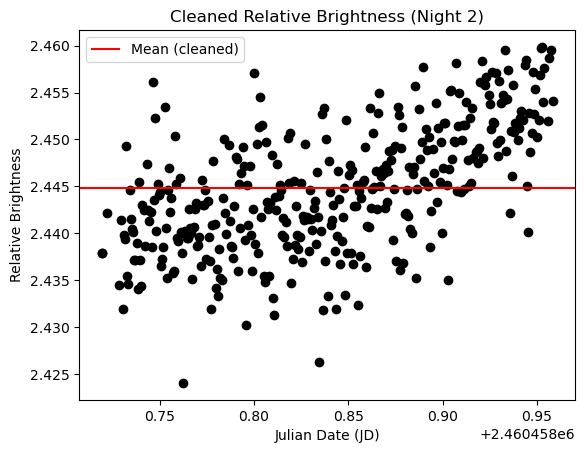

In [22]:
# Identify bad points
low_cut2, high_cut2 = 2.42, 2.46

k2list = [k for k, v in enumerate(starphot2) if v < low_cut2 or v > high_cut2]
print('Bad points have indices', k2list)

# Copy a new list of observations
clean_data2 = [o for k, o in enumerate(night2) if k not in k2list]
clean_obstimes2 = [o.jd for o in clean_data2]
clean_starphot2 = [o.relphot for o in clean_data2]

# Compute statistics
mean_clean2 = myavg(clean_starphot2)
sd_clean2   = mystd(clean_starphot2)
sem_clean2  = mysem(clean_starphot2)

print(f"Mean star flux = {mean_clean2:.5f}")
print(f"Standard deviation = {sd_clean2:.5f}")
print(f"Standard error of mean = {sem_clean2:.5f}")

# Plot cleaned data
fig, ax = plt.subplots()
ax.plot(clean_obstimes2, clean_starphot2, 'ok')
ax.axhline(mean_clean2, color='r', label='Mean (cleaned)')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Relative Brightness')
ax.set_title('Cleaned Relative Brightness (Night 2)')
ax.legend()
plt.show()

### Problem 8

Rescale the relative flux for each night by computing the mean and dividing by that value.
Compute the standard deviation of the rescaled values and discuss how you would use this
to assign an error to the individual data values.


σ (scatter of rescaled flux) = 0.00238


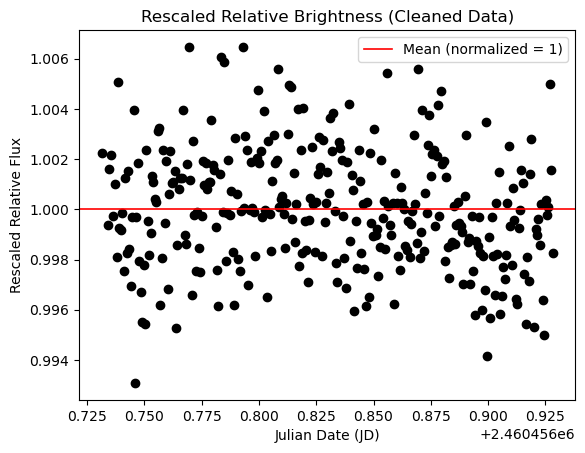

In [23]:
# Rescale each observation so that the mean = 1
for obs in clean_data:
    obs.fscaled = obs.relphot / mean_clean

# Extract rescaled flux values
clean_relflux = [o.fscaled for o in clean_data]

# Compute standard deviation (scatter)
sigma_rescaled = mystd(clean_relflux)
print(f"σ (scatter of rescaled flux) = {sigma_rescaled:.5f}")

# Plot the rescaled relative flux
fig, ax = plt.subplots()
ax.plot(clean_obstimes, clean_relflux, 'ok')
ax.axhline(1.0, color='r', lw=1.2, label='Mean (normalized = 1)')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Rescaled Relative Flux')
ax.set_title('Rescaled Relative Brightness (Cleaned Data)')
ax.legend()
plt.show()

σ (scatter of rescaled flux) = 0.00275


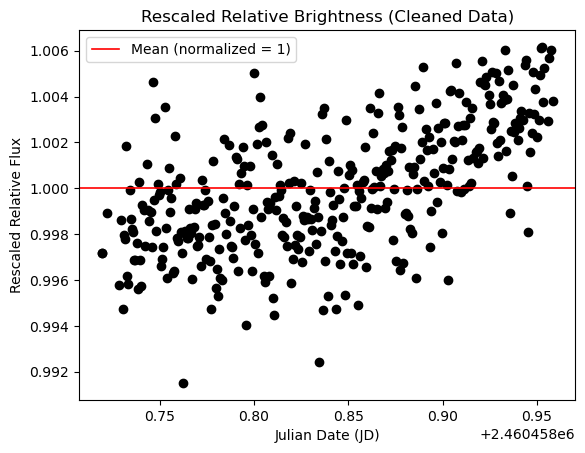

In [24]:
# Rescale each observation so that the mean = 1
for obs in clean_data2:
    obs.fscaled = obs.relphot / mean_clean2

# Extract rescaled flux values
clean_relflux2 = [o.fscaled for o in clean_data2]

# Compute standard deviation (scatter)
sigma_rescaled2 = mystd(clean_relflux2)
print(f"σ (scatter of rescaled flux) = {sigma_rescaled2:.5f}")

# Plot the rescaled relative flux
fig, ax = plt.subplots()
ax.plot(clean_obstimes2, clean_relflux2, 'ok')
ax.axhline(1.0, color='r', lw=1.2, label='Mean (normalized = 1)')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Rescaled Relative Flux')
ax.set_title('Rescaled Relative Brightness (Cleaned Data)')
ax.legend()
plt.show()

### Problem 9

Create averages of points in some chosen bin size.  Plot the relative flux for all points,
then the binned data.  Pick marker styles that make it easy to see the binned data.

Compute the mean and standard deviation of the binned relative flux, and discuss what this means for the errors
in the binned data.

The code below uses [Python list slicing techniques](https://www.geeksforgeeks.org/python/python-list-slicing/). Read this linked document thoroughly,
and in an exercise of code factorization, write a description of how this works.  It also makes use of the important
[Python range() function](https://www.geeksforgeeks.org/python/python-range-function/).

Mean of binned relative flux = 1.00000
Standard deviation of binned flux = 0.00109
Standard error of binned means = 0.00015


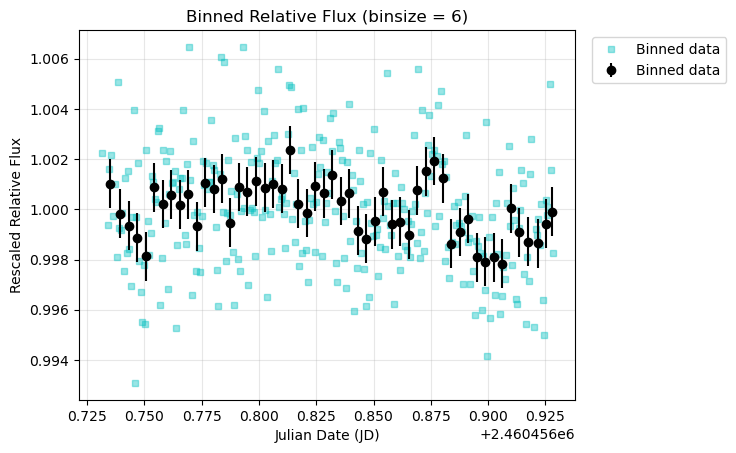

In [25]:
binsize = 6   # number of points per bin (can increase to smooth more)

idx = [j for j in range(len(clean_obstimes))]      # 0, 1, 2, ...

bin_times = []
bin_rflux = []
for i in idx[ : : binsize]:
    j = i + binsize
    time = myavg(clean_obstimes[i:j])
    flux = myavg(clean_relflux[i:j])
    bin_times.append(time)
    bin_rflux.append(flux)

# Compute standard deviation of binned fluxes
bin_std = mystd(bin_rflux)
bin_mean = myavg(bin_rflux)

# Estimate standard error of a single binned mean
bin_sem = bin_std / (len(bin_rflux) ** 0.5)

print(f"Mean of binned relative flux = {bin_mean:.5f}")
print(f"Standard deviation of binned flux = {bin_std:.5f}")
print(f"Standard error of binned means = {bin_sem:.5f}")

# Compute error bar for each bin = SEM of points in that bin
# (approximate using unbinned scatter divided by sqrt(binsize))
erval = mystd(clean_relflux) / (binsize ** 0.5)
bin_errors = [erval for _ in bin_rflux]

# Plot original data + binned data with error bars
fig, ax = plt.subplots()
ax.plot(clean_obstimes, clean_relflux, 'sc', markersize=5, alpha=0.4, label='Binned data')
ax.errorbar(bin_times, bin_rflux, yerr=bin_errors, xerr=None, fmt='ok', label='Binned data')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Rescaled Relative Flux')
ax.set_title(f'Binned Relative Flux (binsize = {binsize})')
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left',)
ax.grid(alpha=0.3)
plt.show()


Mean of binned relative flux = 1.00003
Standard deviation of binned flux = 0.00193
Standard error of binned means = 0.00028


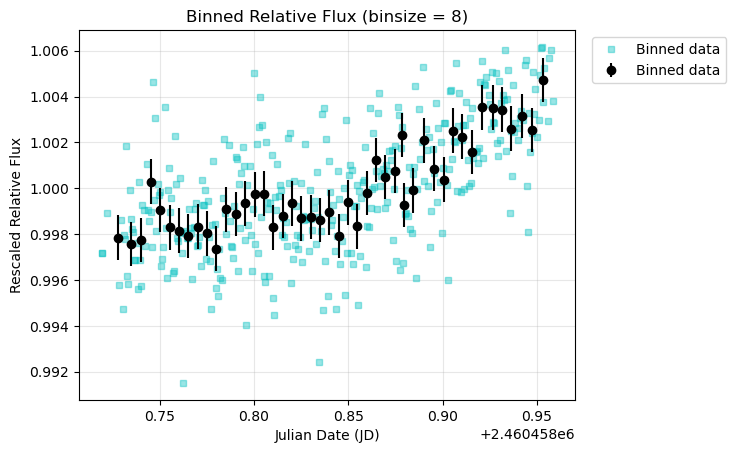

In [26]:
binsize2 = 8   # number of points per bin (can increase to smooth more)

idx2 = [j2 for j2 in range(len(clean_obstimes2))]      # 0, 1, 2, ...

bin_times2 = []
bin_rflux2 = []
for i2 in idx2[ : : binsize2]:
    j2 = i2 + binsize2
    time2 = myavg(clean_obstimes2[i2:j2])
    flux2 = myavg(clean_relflux2[i2:j2])
    bin_times2.append(time2)
    bin_rflux2.append(flux2)

# Compute standard deviation of binned fluxes
bin_std2 = mystd(bin_rflux2)
bin_mean2 = myavg(bin_rflux2)

# Estimate standard error of a single binned mean
bin_sem2 = bin_std2 / (len(bin_rflux2) ** 0.5)

print(f"Mean of binned relative flux = {bin_mean2:.5f}")
print(f"Standard deviation of binned flux = {bin_std2:.5f}")
print(f"Standard error of binned means = {bin_sem2:.5f}")

# Compute error bar for each bin = SEM of points in that bin
# (approximate using unbinned scatter divided by sqrt(binsize))
erval2 = mystd(clean_relflux2) / (binsize2 ** 0.5)
bin_errors2 = [erval2 for _ in bin_rflux2]

# Plot original data + binned data with error bars
fig, ax = plt.subplots()
ax.plot(clean_obstimes2, clean_relflux2, 'sc', markersize=5, alpha=0.4, label='Binned data')
ax.errorbar(bin_times2, bin_rflux2, yerr=bin_errors2, xerr=None, fmt='ok', label='Binned data')
ax.set_xlabel('Julian Date (JD)')
ax.set_ylabel('Rescaled Relative Flux')
ax.set_title(f'Binned Relative Flux (binsize = {binsize2})')
ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left',)
ax.grid(alpha=0.3)
plt.show()


range(len(clean_obstimes)) generates [0, 1, 2, 3, ...] up to the number of data points.
idx[::binsize] means: start at 0, then step forward by binsize each time.
So if binsize = 4, get [0, 4, 8, 12, …].

$$
\sigma_{\text{binned}} \approx \frac{\sigma_{\text{unbinned}}}{\sqrt{N_{\text{bin}}}}
$$



$$
\text{error} = \frac{\sigma_{\text{unbinned}}}{\sqrt{\text{binsize}}}
$$


### Problem 10

Write an analysis of these data.  Is there evidence for a significant change in brightness of
Kepler 90 on one of the two nights?  A significant change means several times the error assigned.
Use list slicing to isolate groups of data values, and apply your satistical functions to justfify
your conclusions.  The plot below shows how to plot data by point number (x-axis value given
0, 1, 2, ...).

**For Night 1**, the relative brightness remains nearly constant around unity for the first half, but small rise on the end about 0.3-0,4% more. Statistical comparison of the first and second halves gives a difference less than ~1–2σ, showing that any change is not statistically significant.

**For Night 2**, a slow upward trend is visible in the binned data with later points slightly brighter than earlier ones. The measured difference between halves corresponds to roughly 2–3 σ, suggesting a possible small systematic brightening, though still marginal compared to the combined photometric uncertainties.

So, The relative-flux analysis for both nights indicates that Kepler 90 remained photometrically stable.
There is no compelling evidence of a true astrophysical change in Kepler 90’s brightness during either observing session.

(0.98, 1.02)

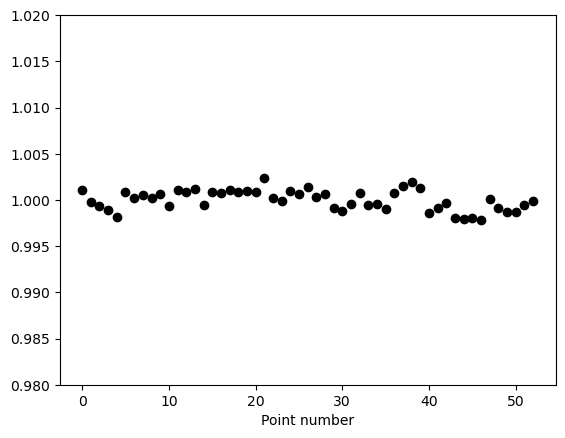

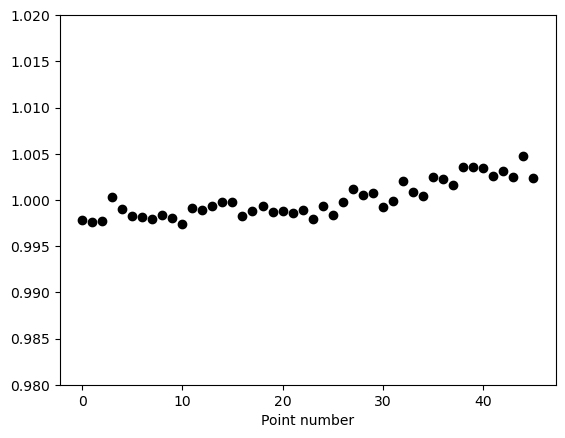

In [27]:
# Plot vs. point number
fig, ax = plt.subplots()
ax.plot(bin_rflux, 'ok', label='Data')    # Don't specify x-axis list
ax.set_xlabel('Point number')
ax.set_ylim(0.98, 1.02)

fig, ax = plt.subplots()
ax.plot(bin_rflux2, 'ok', label='Data')    # Don't specify x-axis list
ax.set_xlabel('Point number')
ax.set_ylim(0.98, 1.02)

